# Visualize fine-tuned mSWE-GNN — Ahr river 100 m
Loads the fine-tuned checkpoint and runs a full rollout on the 100 m additionalsrc dataset.

In [1]:
import sys, os

_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Paths

In [11]:
import shutil, zipfile, os

CHECKPOINT_SRC = os.path.join(REPO_ROOT, 'lightning_logs', 'last-v3.ckpt')
CHECKPOINT_DIR = r'C:\Users\marrocol\AppData\Local\Temp\last-v3.ckpt'
CHECKPOINT     = r'C:\Users\marrocol\AppData\Local\Temp\last-v3-packed.ckpt'
CONFIG         = 'config_finetune_100m_small.yaml'
DATASET_NAME   = 'ahr_river_v03_marg_additionalsrc_100m_cutpolygon'

# last-v3.ckpt is a directory (OneDrive folder checkpoint), not a single file.
# Copy the whole tree to temp, then repack into a single ZIP that torch.load expects.
if os.path.exists(CHECKPOINT_DIR):
    shutil.rmtree(CHECKPOINT_DIR)
shutil.copytree(CHECKPOINT_SRC, CHECKPOINT_DIR)
print('Copied checkpoint directory to:', CHECKPOINT_DIR)

with zipfile.ZipFile(CHECKPOINT, 'w', compression=zipfile.ZIP_STORED) as zf:
    for root, dirs, files in os.walk(CHECKPOINT_DIR):
        for fname in files:
            fpath = os.path.join(root, fname)
            arcname = os.path.relpath(fpath, CHECKPOINT_DIR)
            zf.write(fpath, arcname)
print('Repacked checkpoint to:', CHECKPOINT)

Copied checkpoint directory to: C:\Users\marrocol\AppData\Local\Temp\last-v3.ckpt
Repacked checkpoint to: C:\Users\marrocol\AppData\Local\Temp\last-v3-packed.ckpt


## Load config and dataset

In [12]:
cfg = read_config(CONFIG)
cfg['dataset_parameters']['test_dataset_name']  = DATASET_NAME
cfg['dataset_parameters']['train_dataset_name'] = DATASET_NAME

wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device('cpu')

_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)

print('Test size:', len(test_dataset))
print('WD shape: ', test_dataset[0].WD.shape)

The validation dataset you are using is the training one. Careful!
Test size: 1
WD shape:  torch.Size([30079, 121])


## Load fine-tuned model

In [13]:
temporal_test_dataset = to_temporal_dataset(
    test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters
)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

model_parameters = dict(config.models)
model_type = model_parameters.pop('model_type')
if model_type == 'MSGNN':
    model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

model = get_model(model_type)(
    num_node_features=num_node_features,
    num_edge_features=num_edge_features,
    previous_t=temporal_test_dataset_parameters['previous_t'],
    device=device,
    **model_parameters
).to(device)

plmodule_kwargs = {
    'model': model,
    'lr_info': config['lr_info'],
    'trainer_options': config.trainer_options,
    'temporal_test_dataset_parameters': temporal_test_dataset_parameters
}

plmodule = LightningTrainer.load_from_checkpoint(
    CHECKPOINT, map_location=device, **plmodule_kwargs
)
model = plmodule.model.to(device)
model.eval()
print('Model loaded from:', CHECKPOINT)

Model loaded from: C:\Users\marrocol\AppData\Local\Temp\last-v3-packed.ckpt


## Visualise rollout

In [14]:
plot_rollout = PlotRollout(
    model,
    test_dataset[0],
    scalers=scalers,
    **temporal_test_dataset_parameters
)
print('Total time steps:', plot_rollout.real_rollout.shape[-1])

Total time steps: 120


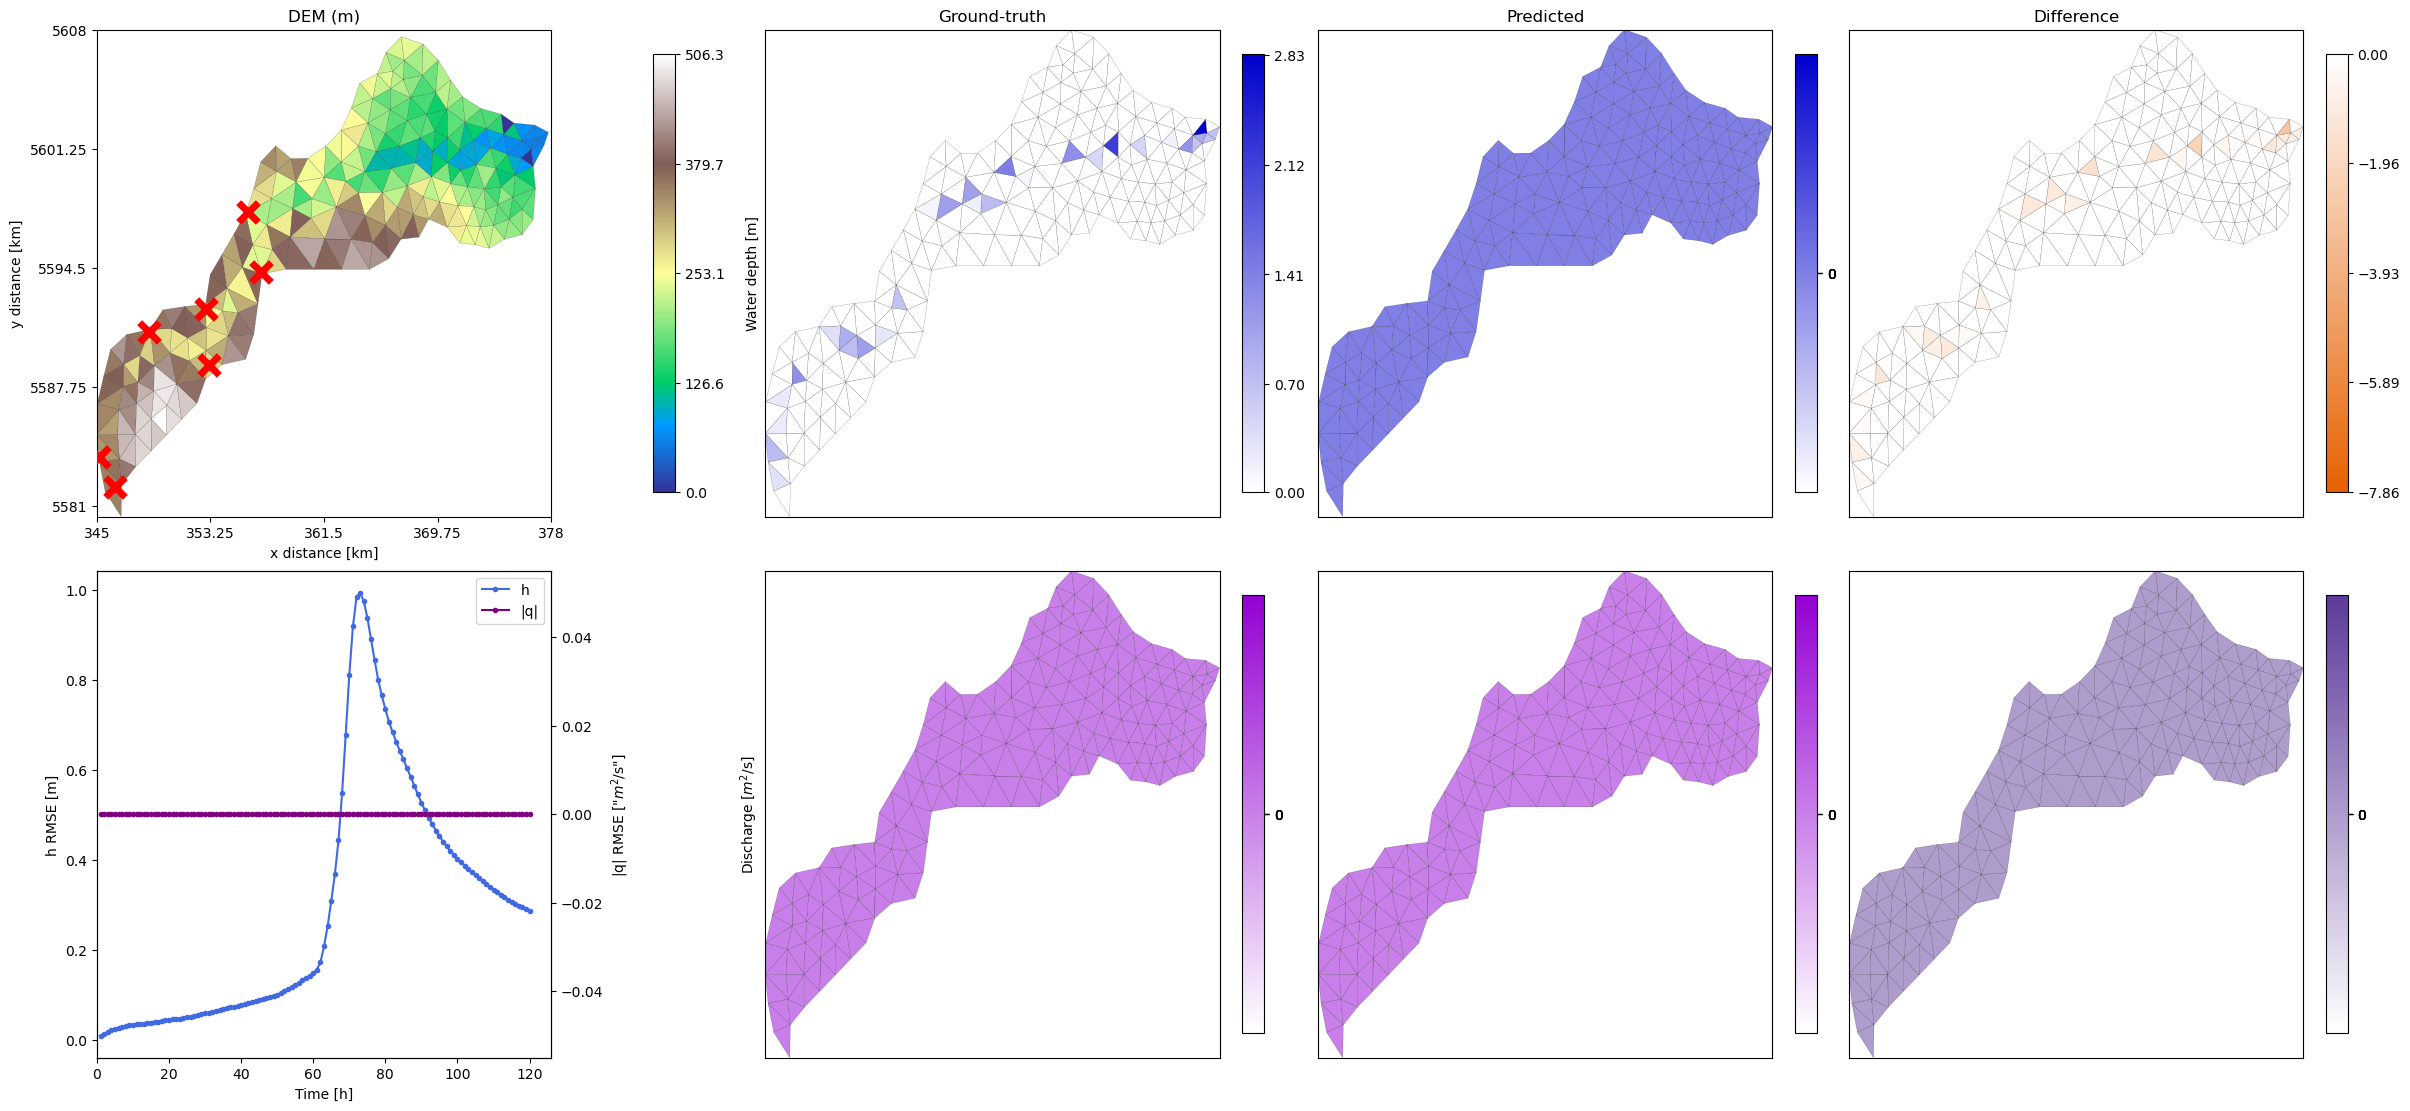

In [15]:
# DEM, ground truth, prediction, difference at the last time step
fig = plot_rollout.explore_rollout(scale=0, time_step=-1)
plt.show()

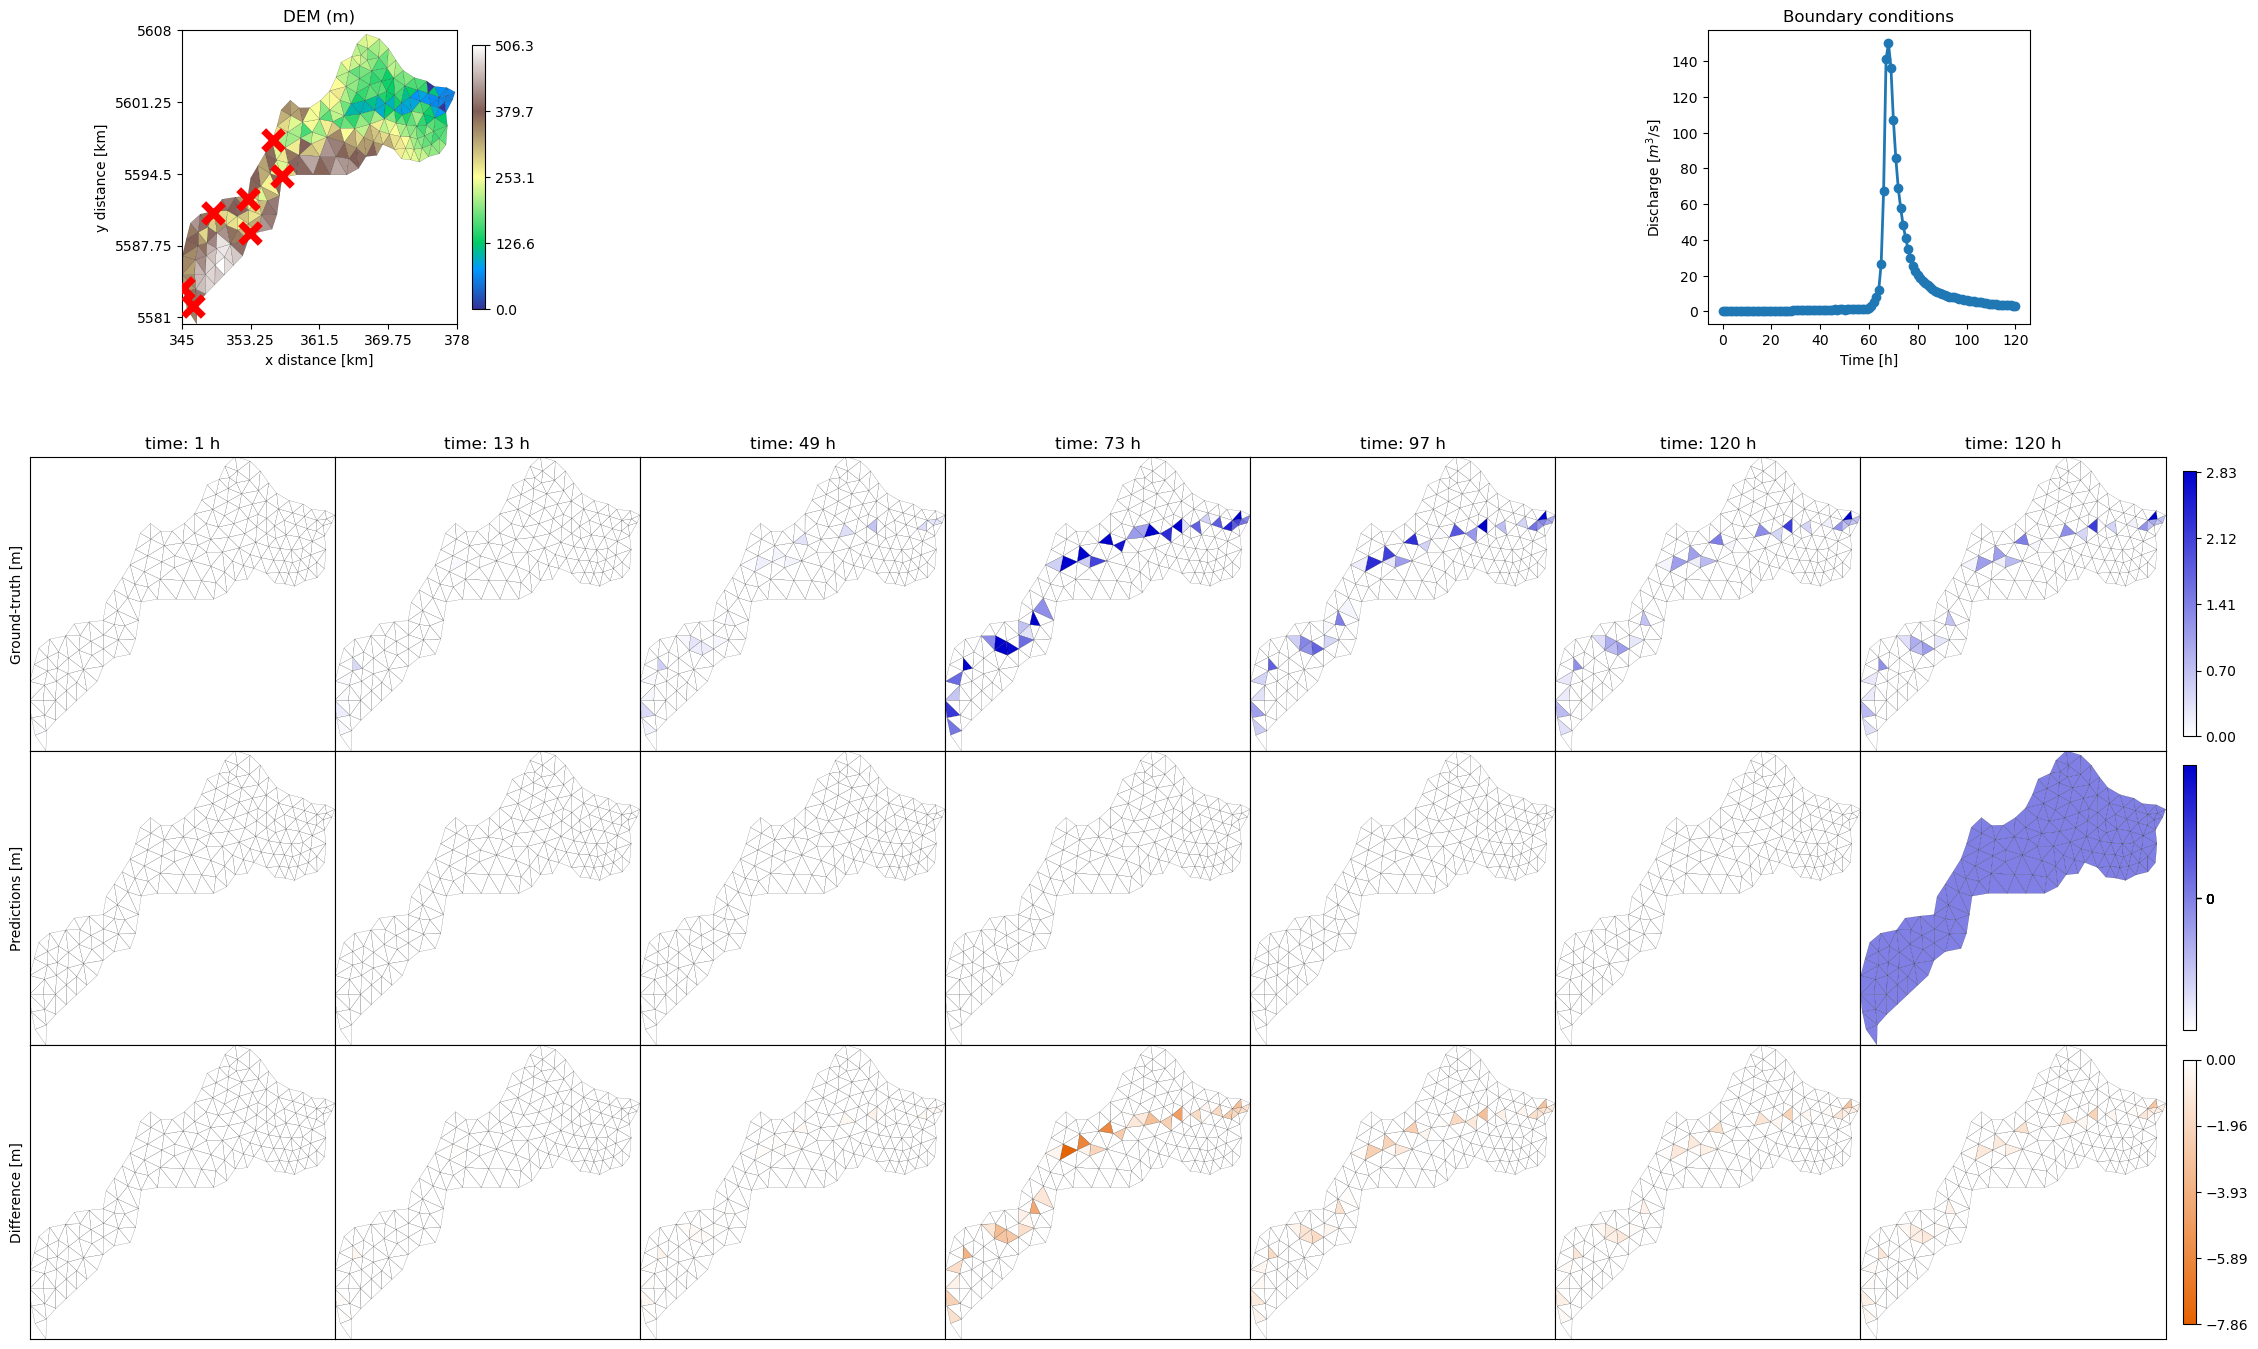

In [16]:
# Water depth maps at selected hours
plot_rollout.compare_h_rollout(plot_times=[0, 12, 48, 72, 96, 119])
plt.show()

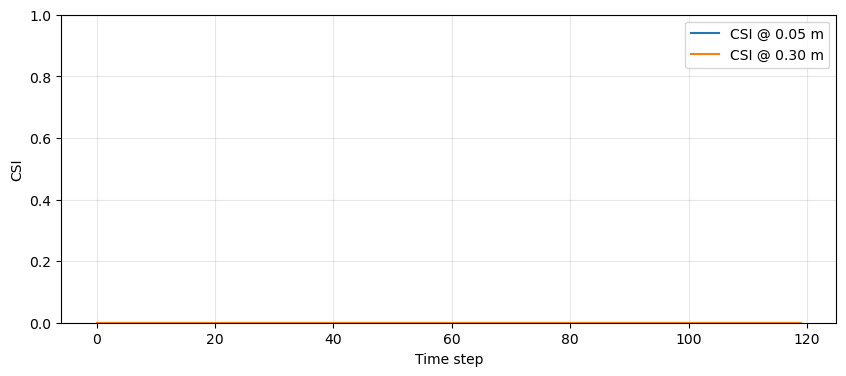

In [19]:
# CSI over time
thresholds = [0.05, 0.30]

fig, ax = plt.subplots(figsize=(10, 4))
for thr in thresholds:
    csi = plot_rollout._get_CSI(water_threshold=thr).detach().cpu().numpy()
    if csi.ndim > 1:
        csi = np.nanmean(csi, axis=0)
    ax.plot(csi, label=f'CSI @ {thr:.2f} m')

ax.set_xlabel('Time step')
ax.set_ylabel('CSI')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Metrics

In [20]:
rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
loss_mean = rollout_loss.mean(0)
if loss_mean.ndim == 0:
    print(f'RMSE WD: {loss_mean.item():.4f} m')
    loss_mean = loss_mean.unsqueeze(0)
else:
    print(f'RMSE WD: {loss_mean[0].item():.4f} m')
if loss_mean.shape[0] > 1:
    print(f'RMSE V:  {loss_mean[1:].mean().item():.4f} m²/s')

csi_005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
csi_03  = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()
print(f'CSI @ 0.05 m: {csi_005:.4f}')
print(f'CSI @ 0.30 m: {csi_03:.4f}')

RMSE WD: 0.1422 m
CSI @ 0.05 m: 0.0000
CSI @ 0.30 m: 0.0000
